In [12]:
import os
import re
import math
import torch
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gidd.eval.generation_info import GenerationInfoHandler
from datasets import load_from_disk

mask_token_id = 9

In [13]:
# Load data
base_dir = "generation_info"
num_dirs = len([name for name in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, name))])
combination_row_ids = [i + 1 for i in range(num_dirs)]

dir_path_dict = {}
meta_dict = {}
history_dict = {}
logits_dict = {}
confidence_t_0_dict = {}
marginals_dict = {}
change_events_table_dict = {}
forward_calls_dict = {}
prune_correct_dict = {}
beam_search_forward_calls_dict = {}
beam_search_branch_correctness_dict = {}
beam_search_beam_correctness_dict = {}
denoise_config_dict = {}
combination_rows = []

for combination_row in combination_row_ids:
    dir_path = f"{base_dir}/combination_{combination_row}"
    meta, history, logits, confidence_t_0, marginals, change_events_table, forward_calls, prune_correct, beam_search_forward_calls, beam_search_branch_correctness, beam_search_beam_correctness = GenerationInfoHandler.load_all(dir_path)
    dir_path_dict[combination_row] = dir_path
    meta_dict[combination_row] = meta
    history_dict[combination_row] = history
    logits_dict[combination_row] = logits
    confidence_t_0_dict[combination_row] = confidence_t_0
    marginals_dict[combination_row] = marginals
    change_events_table_dict[combination_row] = change_events_table
    forward_calls_dict[combination_row] = forward_calls
    prune_correct_dict[combination_row] = prune_correct
    beam_search_forward_calls_dict[combination_row] = beam_search_forward_calls
    beam_search_branch_correctness_dict[combination_row] = beam_search_branch_correctness
    beam_search_beam_correctness_dict[combination_row] = beam_search_beam_correctness
    denoise_config_dict[combination_row] = meta['sampling_strategy']['p_denoise']

    sampling_parameters = meta['sampling_strategy'].copy()
    if isinstance(sampling_parameters.get('p_denoise', None), dict):
        for k, v in sampling_parameters['p_denoise'].items():
            sampling_parameters[f'p_denoise_{k}'] = v
        del sampling_parameters['p_denoise']
    sampling_parameters['combination_row'] = combination_row
    combination_rows.append(sampling_parameters)

combinations_df = pd.DataFrame(combination_rows)

print(meta_dict[combination_row_ids[0]])

{'accuracy': 0.8125, 'correctly_filled_cells': 0.9175319075584412, 'nfe': 1.25, 'time_taken_s': 3.8578648567199707, 'speed_samples_per_s': 16.589487288161255, 'created_at': '2025-11-17 11:40:22 GMT', 'num_samples': 64, 'max_seq_len': 81, 'collect_history': True, 'collect_logits': True, 'collect_confidence_t_0': False, 'collect_marginals': True, 'collect_change_events': True, 'collect_forward_calls': True, 'collect_prune_correct': False, 'collect_beam_search_forward_calls': False, 'collect_beam_search_branch_correctness': False, 'collect_beam_search_beam_correctness': False, 'general_sampling': {'device': 0, 'seed': 1, 'checkpoint': 'checkpoints/gidd_0_2/300_epochs', 'dataset': 'hard', 'num_samples': 64, 'num_denoising_steps': 80, 'num_self_correction_steps': 0, 'batch_size': 64, 'min_p': 0.0, 'compile_torch': 0, 'combinations_row': 1}, 'sampling_strategy': {'strategy': 'gidd_change_based_on_model_confidence_to_change', 'time_steps': 'inferred', 'score_mask_position': None, 'score_posit

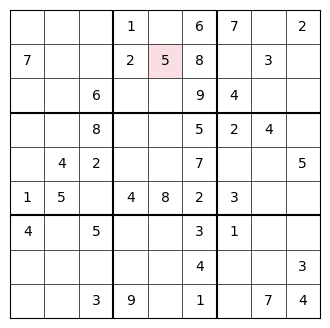

In [14]:
from matplotlib.patches import Rectangle
def visualize_sudoku_only(sample, time_step, logits, history, show_solution_instead=False):
    solution = history[:, -1, :]
    history = history[:, :-1, :]
    seq_len = history.shape[-1]
    vocab_size = logits.shape[-1]
    z_t = history[sample, time_step]
    if show_solution_instead:
        z_t = solution[sample]

    rows = math.ceil(math.sqrt(seq_len))
    cols = seq_len // rows + (1 if seq_len % rows != 0 else 0)

    fig, (ax1) = plt.subplots(1, 1, figsize=(4, 4))
    
    # thin grid lines
    ax1.grid(which="minor", color="black", linewidth=0.5)

    # ---- Figure 1: token grid ----
    grid = np.full((rows, cols), -1, dtype=np.int32)
    upto = min(seq_len, rows * cols)
    grid.flat[:upto] = z_t[:upto]

    ax1.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax1.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax1.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    # overlay token values
    for i in range(upto):
        r, c = divmod(i, cols)
        token = int(z_t[i])
        token_str = str(token + 1) if token != mask_token_id else ""
        ax1.text(c, r, token_str, ha="center", va="center")
    
    # fill incorrect cells
    incorrect_mask = (z_t != solution[sample]) & (z_t != mask_token_id)
    incorrect_indices = np.flatnonzero(incorrect_mask)
    for i in incorrect_indices:
        if i >= upto:
            continue
        r, c = divmod(i, cols)
        ax1.add_patch(Rectangle(
            (c - 0.5, r - 0.5), 1, 1,
            facecolor="#f8d7da",  # light red
            edgecolor="none",
            alpha=0.8,
            zorder=0.1  # behind text/selection, ahead of background
        ))

    # thick box lines
    if rows == cols:
        box = int(math.sqrt(rows))
        for r in range(box, rows, box):
            ax1.axhline(r-0.5, color="black", linewidth=1.5)
        for c in range(box, cols, box):
            ax1.axvline(c-0.5, color="black", linewidth=1.5)
    
    plt.savefig(dir_path_dict[combination_row] + '/sudoku.png')


combination_row = 1
sample = 0
time_step = 12
visualize_sudoku_only(sample, time_step, logits_dict[combination_row], history_dict[combination_row][:, :, :])

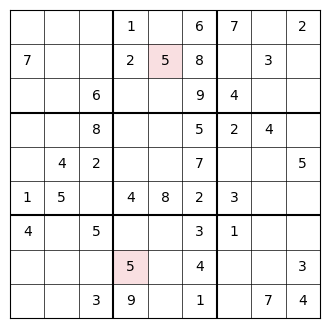

In [15]:
visualize_sudoku_only(sample, time_step + 1, logits_dict[combination_row], history_dict[combination_row][:, :, :])

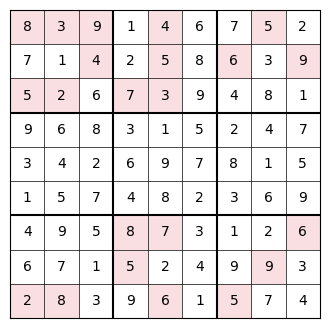

In [16]:
visualize_sudoku_only(sample, time_step + 68, logits_dict[combination_row], history_dict[combination_row][:, :, :])

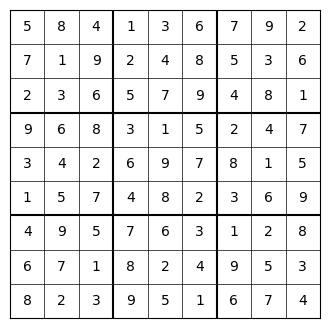

In [17]:
visualize_sudoku_only(sample, time_step, logits_dict[combination_row], history_dict[combination_row][:, :, :], show_solution_instead=True)